In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
#machine learning modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#setting visuals
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
print("ENVIRONMENT INITIALIZED. ALL PREMIUM ENGINEERING ENGINES ARE ONLINE !!.")

ENVIRONMENT INITIALIZED. ALL PREMIUM ENGINEERING ENGINES ARE ONLINE !!.


In [2]:
df = pd.read_csv(r'C:\Users\Shruti singh\Downloads\archive\train.csv')
print("DATASET LOADED SUCCESSFULLY ON YOUR DEVICE!!")
print("!!!! DATA STRUCTURE SUMMARY !!!!")
print(df.info())
print("SHAPE:",df.shape)



DATASET LOADED SUCCESSFULLY ON YOUR DEVICE!!
!!!! DATA STRUCTURE SUMMARY !!!!
<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  str    
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  str    
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  str    
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 2.7 MB
None
SHAPE: (29451, 12)


In [3]:
print("!!!! MISSING VALUE AUDIT !!!!")
print(df.isnull().sum())

df.head()

!!!! MISSING VALUE AUDIT !!!!
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [4]:
#stastical summary before cleaning
print("BEFORE CLEANING - MAX SQUARE FT :",df['SQUARE_FT'].max())
#computing iqr boundaries for square footage
q_low = df["SQUARE_FT"].quantile(0.01)
q_high = df["SQUARE_FT"].quantile(0.99)

#filtering structural outliers
df = df[(df["SQUARE_FT"]< q_high) & (df["SQUARE_FT"]> q_low)]

#caps the target pricing at 500 lakhs i.e; 5 cr to handle extreme pricing skewness
df = df[df["TARGET(PRICE_IN_LACS)"] < 500]

print(f"AFTER CLEANING - SHAPE : {df.shape[0]} rows. OUTLIERS SUCCESSFULLY PRUNED")

BEFORE CLEANING - MAX SQUARE FT : 254545454.5
AFTER CLEANING - SHAPE : 28335 rows. OUTLIERS SUCCESSFULLY PRUNED


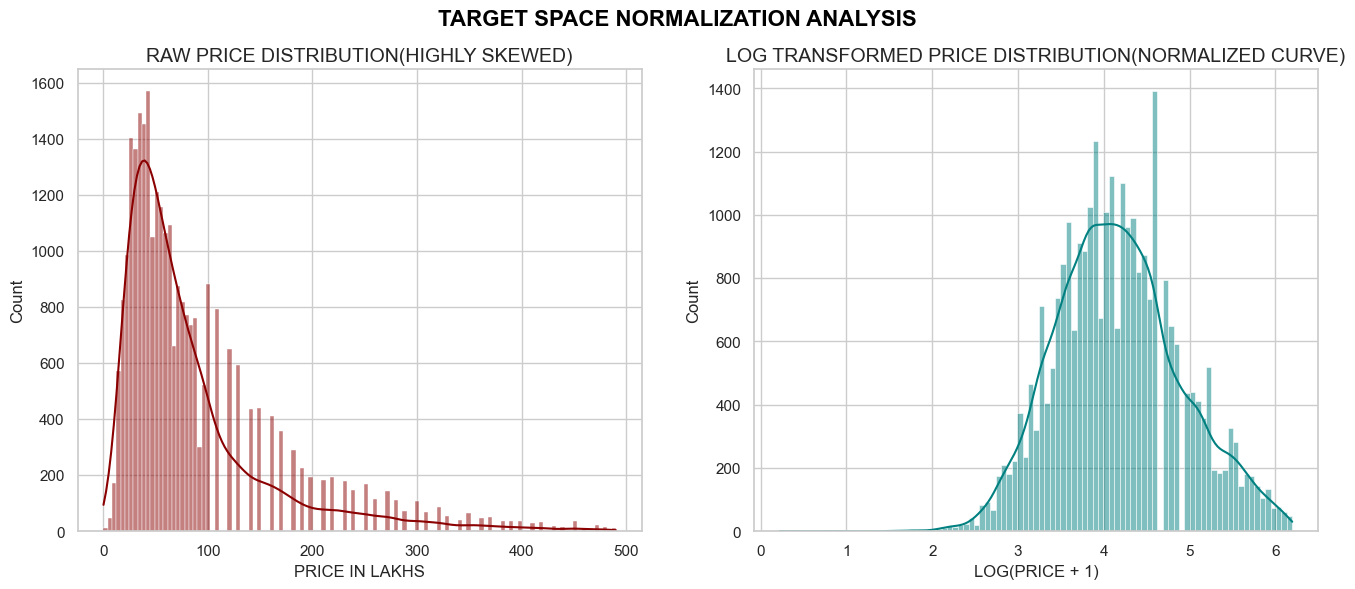

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
#plot 1 : raw target distribution
sns.histplot(df["TARGET(PRICE_IN_LACS)"], kde=True, ax= axes[0],color="darkred")
axes[0].set_title("RAW PRICE DISTRIBUTION(HIGHLY SKEWED)")
axes[0].set_xlabel("PRICE IN LAKHS")
#plot 2: log transformed target distribution
sns.histplot(np.log1p(df["TARGET(PRICE_IN_LACS)"]), kde=True,ax=axes[1], color="teal")
axes[1].set_title("LOG TRANSFORMED PRICE DISTRIBUTION(NORMALIZED CURVE)")
axes[1].set_xlabel("LOG(PRICE + 1)")

plt.suptitle("TARGET SPACE NORMALIZATION ANALYSIS", fontsize=16, color="black",weight='bold')
plt.show()

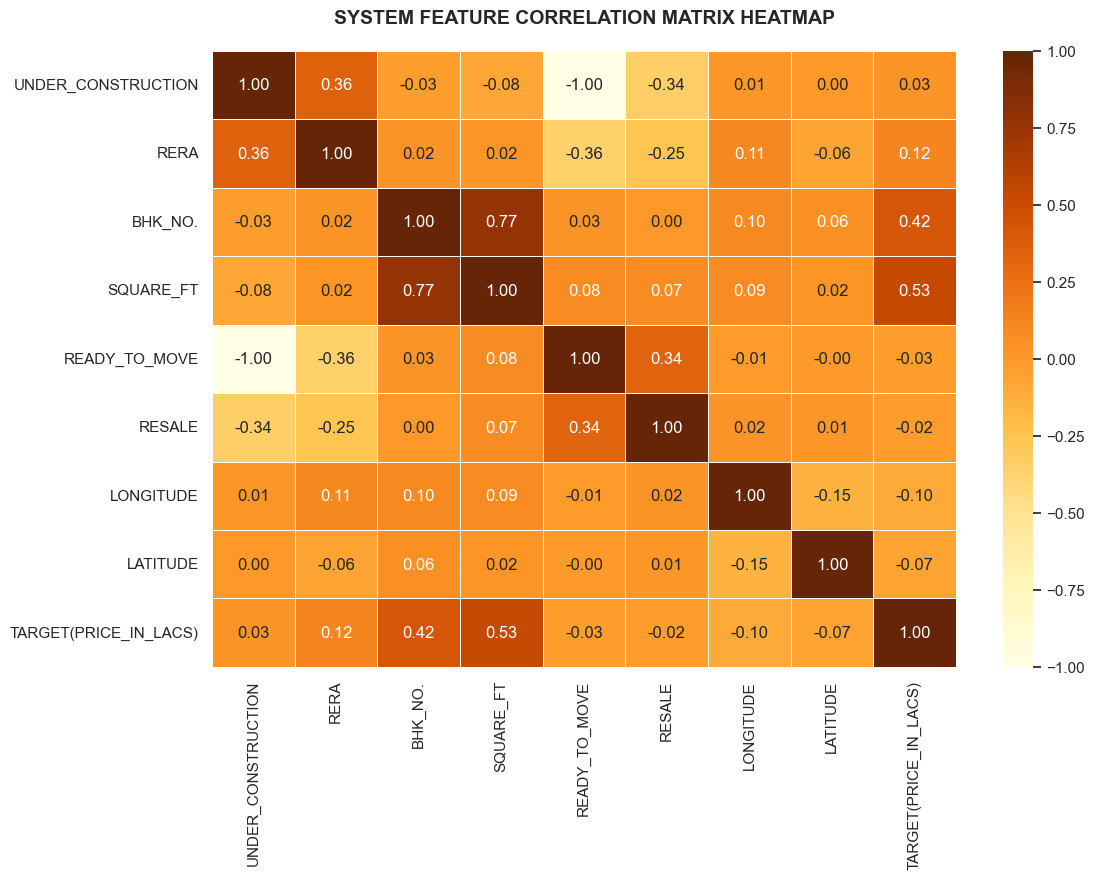

In [6]:
#isolate only numeric feature columns for mathematical matrix evaluation
numeric_df = df.select_dtypes(include=[np.number])

#compute correlation matrix
corr_matrix = numeric_df.corr()

#sns heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True,cmap="YlOrBr",fmt=".2f",linewidths=0.5,cbar=True)
plt.title("SYSTEM FEATURE CORRELATION MATRIX HEATMAP",pad=20,weight="bold")
plt.show()


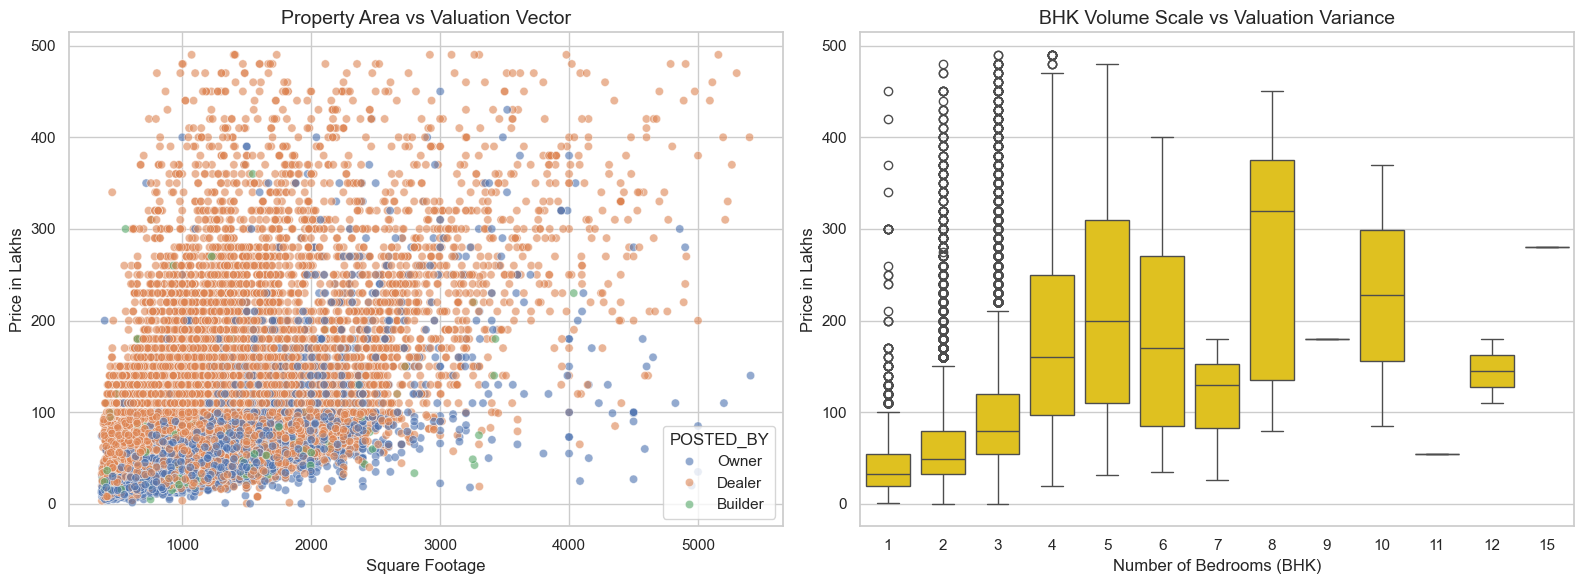

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Area vs Price Trend Line Evaluation
sns.scatterplot(data=df, x='SQUARE_FT', y='TARGET(PRICE_IN_LACS)', hue='POSTED_BY', alpha=0.6, ax=axes[0])
axes[0].set_title("Property Area vs Valuation Vector")
axes[0].set_xlabel("Square Footage")
axes[0].set_ylabel("Price in Lakhs")

# Plot 2: Structural Configuration Pricing Distribution
sns.boxplot(data=df, x='BHK_NO.', y='TARGET(PRICE_IN_LACS)', color='gold', ax=axes[1] )
axes[1].set_title("BHK Volume Scale vs Valuation Variance")
axes[1].set_xlabel("Number of Bedrooms (BHK)")
axes[1].set_ylabel("Price in Lakhs")

plt.tight_layout()
plt.show()

In [11]:
# Feature Injection 1: Room Density Indicator
df['SQFT_PER_BHK'] = df['SQUARE_FT'] / (df['BHK_NO.'] + 0.1)

# Feature Injection 2: Statutory Trust Coefficient Index
df['TRUST_SCORE'] = df['RERA'] + df['READY_TO_MOVE'] - df['UNDER_CONSTRUCTION']

# Feature Injection 3: Geographic Macro Extraction
df['CITY'] = df['ADDRESS'].apply(lambda x: x.split(',')[-1].strip().upper())

# Constrain high cardinal cities to top 15 tiers to optimize frontend deployment footprint
top_cities = df['CITY'].value_counts().index[:15].tolist()
df['CITY'] = df['CITY'].apply(lambda x: x if x in top_cities else 'OTHER')

print("Interaction variables engineered. Feature vectors enriched.")
df[['SQFT_PER_BHK', 'TRUST_SCORE', 'CITY']].head()

Interaction variables engineered. Feature vectors enriched.


,SQFT_PER_BHK,TRUST_SCORE,CITY
0,619.160194,1,BANGALORE
1,607.142857,1,OTHER
2,444.361772,1,BANGALORE
3,442.819592,2,GHAZIABAD
4,475.718689,-1,KOLKATA


In [12]:
le_posted = LabelEncoder()
df['POSTED_BY'] = le_posted.fit_transform(df['POSTED_BY'])

le_bhk_rk = LabelEncoder()
df['BHK_OR_RK'] = le_bhk_rk.fit_transform(df['BHK_OR_RK'])

le_city = LabelEncoder()
df['CITY'] = le_city.fit_transform(df['CITY'])

print("✅ Categorical columns converted to numeric indices via LabelEncoding.")

✅ Categorical columns converted to numeric indices via LabelEncoding.


In [13]:
# Map input vector dimensions
X = df[['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK', 
        'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'SQFT_PER_BHK', 'TRUST_SCORE', 'CITY']]

# Apply Log Stabilization to handle mathematical pricing variance
y = np.log1p(df['TARGET(PRICE_IN_LACS)'])

# Execute Train-Test Train Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Splitting Complete. Training Vector Shape: {X_train.shape}, Test Vector Shape: {X_test.shape}")

✅ Splitting Complete. Training Vector Shape: (22668, 11), Test Vector Shape: (5667, 11)


In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost Regressor": XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42)
}

trained_predictions = {}

for name, model in models.items():
    print(f"⏳ Training {name} architecture...")
    model.fit(X_train, y_train)
    
    # Store predictions in a temporary dictionary wrapper
    trained_predictions[name] = model.predict(X_test)
    print(f"✅ {name} processing complete.")

⏳ Training Linear Regression architecture...
✅ Linear Regression processing complete.
⏳ Training Random Forest Regressor architecture...
✅ Random Forest Regressor processing complete.
⏳ Training XGBoost Regressor architecture...
✅ XGBoost Regressor processing complete.


In [15]:
performance_summary = {
    "Model Architecture": [],
    "R² Score (Accuracy)": [],
    "MAE (Lakhs)": [],
    "MSE (Lakhs²)": [],
    "RMSE (Lakhs)": []
}

# Invert Log Transformation vectors back to raw Lakh valuation units for realistic benchmarking
true_y_lakhs = np.expm1(y_test)

for name, preds in trained_predictions.items():
    pred_y_lakhs = np.expm1(preds)
    
    # Mathematical calculation calls
    mae  = mean_absolute_error(true_y_lakhs, pred_y_lakhs)
    mse  = mean_squared_error(true_y_lakhs, pred_y_lakhs)
    rmse = np.sqrt(mse)
    r2   = r2_score(true_y_lakhs, pred_y_lakhs)
    
    # Append parameters to summary matrix dictionary
    performance_summary["Model Architecture"].append(name)
    performance_summary["R² Score (Accuracy)"].append(f"{r2*100:.2f}%")
    performance_summary["MAE (Lakhs)"].append(round(mae, 3))
    performance_summary["MSE (Lakhs²)"].append(round(mse, 3))
    performance_summary["RMSE (Lakhs)"].append(round(rmse, 3))

# Display as a clean, presentation-ready Pandas DataFrame
metrics_report_df = pd.DataFrame(performance_summary)
metrics_report_df

,Model Architecture,R² Score (Accuracy),MAE (Lakhs),MSE (Lakhs²),RMSE (Lakhs)
0,Linear Regression,24.25%,37.786,4104.236,64.064
1,Random Forest Regressor,65.12%,24.413,1889.877,43.473
2,XGBoost Regressor,67.49%,23.715,1761.424,41.969


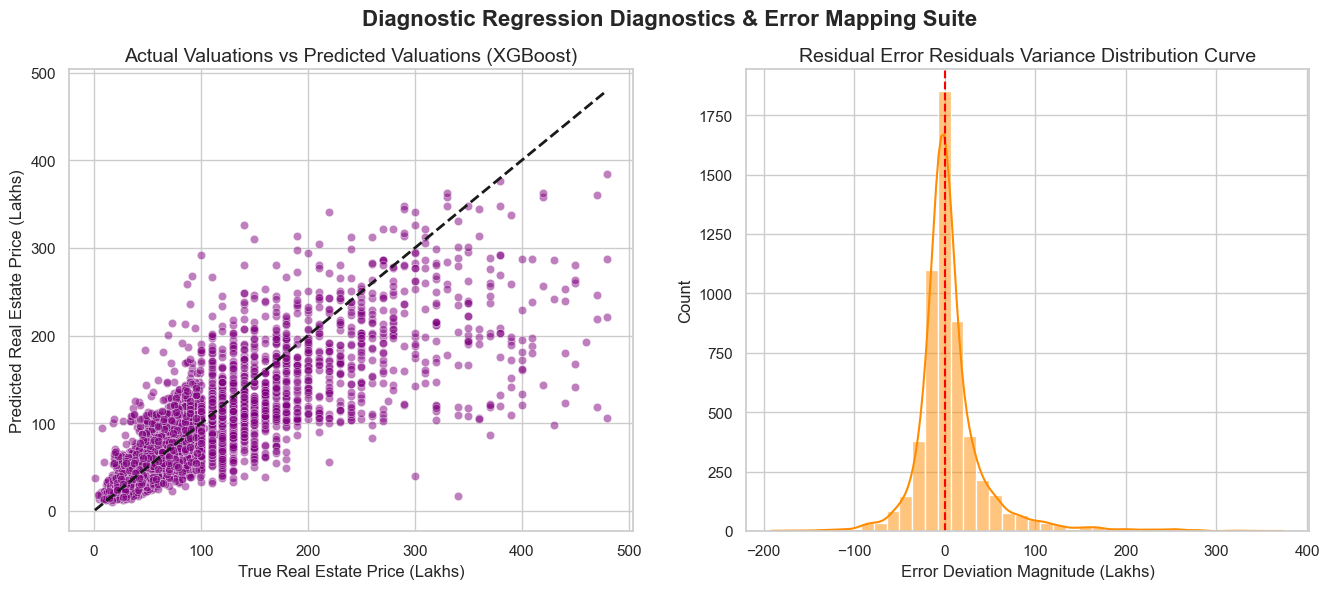

In [16]:
# Extract predictions from our top-performing model architecture (typically XGBoost or Random Forest)
champion_preds = np.expm1(trained_predictions["XGBoost Regressor"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted Pricing Accuracy Convergence Line
sns.scatterplot(x=true_y_lakhs, y=champion_preds, alpha=0.5, color='purple', ax=axes[0])
axes[0].plot([true_y_lakhs.min(), true_y_lakhs.max()], [true_y_lakhs.min(), true_y_lakhs.max()], 'k--', lw=2)
axes[0].set_title("Actual Valuations vs Predicted Valuations (XGBoost)")
axes[0].set_xlabel("True Real Estate Price (Lakhs)")
axes[0].set_ylabel("Predicted Real Estate Price (Lakhs)")

# Plot 2: Residual Error Variance Distribution Plot
residuals = true_y_lakhs - champion_preds
sns.histplot(residuals, kde=True, color='darkorange', ax=axes[1], bins=40)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title("Residual Error Residuals Variance Distribution Curve")
axes[1].set_xlabel("Error Deviation Magnitude (Lakhs)")

plt.suptitle("Diagnostic Regression Diagnostics & Error Mapping Suite", fontsize=16, weight='bold')
plt.show()

In [18]:
# Automatically select champion architecture instance object configuration
champion_model_object = models["XGBoost Regressor"]

# Compile all asset dependencies into a unified pickle bundle
production_artifacts = {
    'model': champion_model_object,
    'le_posted': le_posted,
    'le_bhk_rk': le_bhk_rk,
    'le_city': le_city,
    'top_cities': top_cities,
    'metrics': {
        name: {
            'R2': r2_score(true_y_lakhs, np.expm1(preds)),
            'MAE': mean_absolute_error(true_y_lakhs, np.expm1(preds)),
            'RMSE': np.sqrt(mean_squared_error(true_y_lakhs, np.expm1(preds)))
        } for name, preds in trained_predictions.items()
    }
}

# Export artifact payload securely to disc file systems
with open('sovereign_model.pkl', 'wb') as f:
    pickle.dump(production_artifacts, f)

print("Elite model payloads compiled and exported to 'sovereign_model.pkl'. Ready to power your premium Streamlit app!")

Elite model payloads compiled and exported to 'sovereign_model.pkl'. Ready to power your premium Streamlit app!
